<a href="https://colab.research.google.com/github/liangjizhu/ArendizajeAutomatico/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción del Abandono de Empleados
# **Objetivo:**  
Predecir si un empleado abandonará la empresa (burnout/attrition) mediante diversas técnicas de aprendizaje automático.
# **Estructura del Notebook:**
1. Introducción y Objetivos
2. Exploración de Datos (EDA)
3. Preprocesamiento de los Datos (pipelines, escalado e imputación)
4. Modelado:  
    - Modelos básicos: KNN y Árboles  
    - Modelos avanzados: Regresión Logística y SVM  
5. Evaluación interna (inner) y selección del modelo final
6. Guardado del modelo final
7. Conclusiones y comentarios (incluyendo el uso de ChatGPT)
#
**Nota:** Se utiliza el dataset `attrition_availabledata_05.csv` ubicado en la carpeta `lab1/data/`.



In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OneHotEncoder, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.dummy import DummyClassifier


# Fijamos la semilla para la reproducibilidad (NIA)
SEED = 495723
np.random.seed(SEED)

## 2. Carga y Exploración de Datos (EDA)

En esta sección se carga el dataset, se exploran sus dimensiones, tipos de variables (categóricas, ordinales o numéricas), valores faltantes y el balance de la variable objetivo.


In [162]:
# 1. Cargamos el dataset
data_path = "lab1/data/attrition_availabledata_05.csv"
df = pd.read_csv(data_path)

# 2. Dimensiones y primeras filas
print("En esta primera exploración hemos podido observar que la dimensión de nuestro dataset es:", df.shape)
print("\nPor ejemplo, las 5 primeras filas del dataset se ven así:")
display(df.head())

En esta primera exploración hemos podido observar que la dimensión de nuestro dataset es: (2940, 31)

Por ejemplo, las 5 primeras filas del dataset se ven así:


,hrs,absences,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,BusinessTravel,Department,...,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,6.612625,18,4,3,3.0,3.0,2.0,31,Travel_Frequently,Sales,...,Y,17,8,0,2.0,3,2,2,2,Yes
1,6.026815,18,3,3,4.0,4.0,2.0,31,Travel_Frequently,Sales,...,Y,18,8,1,9.0,3,5,1,4,No
2,6.966456,11,3,3,4.0,1.0,3.0,33,Travel_Frequently,Human Resources,...,Y,14,8,3,5.0,2,4,0,3,No
3,6.678438,12,4,3,4.0,1.0,1.0,48,Travel_Rarely,Research & Development,...,Y,13,8,1,21.0,3,3,0,2,No
4,6.235761,10,3,3,3.0,3.0,2.0,42,Non-Travel,Research & Development,...,Y,18,8,0,10.0,2,6,3,3,No


In [163]:
# 3. Información general de columnas
print("\nInformación general del DataFrame:")
df.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   hrs                      2940 non-null   float64
 1   absences                 2940 non-null   int64  
 2   JobInvolvement           2940 non-null   int64  
 3   PerformanceRating        2940 non-null   int64  
 4   EnvironmentSatisfaction  2924 non-null   float64
 5   JobSatisfaction          2923 non-null   float64
 6   WorkLifeBalance          2920 non-null   float64
 7   Age                      2940 non-null   int64  
 8   BusinessTravel           2940 non-null   object 
 9   Department               2940 non-null   object 
 10  DistanceFromHome         2940 non-null   int64  
 11  Education                2940 non-null   int64  
 12  EducationField           2940 non-null   object 
 13  EmployeeCount            2940 non-null   i

In [164]:
# 4. Tipos de variables
print("\nLos tipos de variable de las 31 columnas:")
print(df.dtypes)


Los tipos de variable de las 31 columnas:
hrs                        float64
absences                     int64
JobInvolvement               int64
PerformanceRating            int64
EnvironmentSatisfaction    float64
JobSatisfaction            float64
WorkLifeBalance            float64
Age                          int64
BusinessTravel              object
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeID                   int64
Gender                      object
JobLevel                     int64
JobRole                     object
MaritalStatus               object
MonthlyIncome                int64
NumCompaniesWorked         float64
Over18                      object
PercentSalaryHike            int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears          float64
TrainingTimesLastYear        int64
YearsAtCompa

In [165]:
# 5. Estadísticas descriptivas de columnas numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("\nEstadísticas descriptivas (numéricas), para ello seleccionamos las de tipo entero y coma floantante:")
display(df[num_cols].describe())


Estadísticas descriptivas (numéricas), para ello seleccionamos las de tipo entero y coma floantante:


,hrs,absences,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,DistanceFromHome,Education,...,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
count,2940.000000,2940.00000,2940.000000,2940.000000,2924.000000,2923.000000,2920.000000,2940.000000,2940.000000,2940.000000,...,2940.000000,2927.000000,2940.000000,2940.0,2940.000000,2934.000000,2940.000000,2940.000000,2940.000000,2940.000000
mean,7.307853,12.67517,2.719728,3.152721,2.717510,2.735546,2.755822,36.973129,9.342517,2.896599,...,64211.180272,2.703792,15.184694,8.0,0.796599,11.332993,2.801020,7.026531,2.200680,4.193537
std,1.320261,5.53976,0.719877,0.359780,1.097171,1.093910,0.706477,9.180117,8.144996,1.028112,...,46952.962747,2.475456,3.613927,0.0,0.847382,7.780129,1.280444,6.076240,3.221736,3.590415
min,5.416880,1.00000,1.000000,3.000000,1.000000,1.000000,1.000000,18.000000,1.000000,1.000000,...,10090.000000,0.000000,11.000000,8.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.280077,8.00000,2.000000,3.000000,2.000000,2.000000,2.000000,30.000000,2.000000,2.000000,...,28575.000000,1.000000,12.000000,8.0,0.000000,6.000000,2.000000,3.000000,0.000000,2.000000
50%,7.022724,13.00000,3.000000,3.000000,3.000000,3.000000,3.000000,36.000000,7.000000,3.000000,...,48050.000000,2.000000,14.000000,8.0,1.000000,10.000000,3.000000,5.000000,1.000000,3.000000
75%,7.888818,17.00000,3.000000,3.000000,4.000000,4.000000,3.000000,43.000000,14.000000,4.000000,...,82370.000000,4.000000,18.000000,8.0,1.000000,15.000000,3.000000,10.000000,3.000000,7.000000
max,10.907255,24.00000,4.000000,4.000000,4.000000,4.000000,4.000000,60.000000,29.000000,5.000000,...,199990.000000,9.000000,25.000000,8.0,3.000000,40.000000,6.000000,40.000000,15.000000,17.000000


In [166]:
# 6. Revisión de valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
hrs                         0
absences                    0
JobInvolvement              0
PerformanceRating           0
EnvironmentSatisfaction    16
JobSatisfaction            17
WorkLifeBalance            20
Age                         0
BusinessTravel              0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeID                  0
Gender                      0
JobLevel                    0
JobRole                     0
MaritalStatus               0
MonthlyIncome               0
NumCompaniesWorked         13
Over18                      0
PercentSalaryHike           0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           6
TrainingTimesLastYear       0
YearsAtCompany              0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
Attrition                   0
dtype: int64


In [167]:
# 7. Análisis de columnas categóricas
cat_cols = df.select_dtypes(include=['object']).columns
if len(cat_cols) > 0:
    print("\nColumnas categóricas y sus valores únicos:")
    for col in cat_cols:
        print(f"\nColumna: {col}")
        print("Valores únicos:", df[col].unique())
        print("Conteo de valores:\n", df[col].value_counts(dropna=False))
else:
    print("\nNo se encontraron columnas categóricas (object).")


Columnas categóricas y sus valores únicos:

Columna: BusinessTravel
Valores únicos: ['Travel_Frequently' 'Travel_Rarely' 'Non-Travel']
Conteo de valores:
 BusinessTravel
Travel_Rarely        2045
Travel_Frequently     573
Non-Travel            322
Name: count, dtype: int64

Columna: Department
Valores únicos: ['Sales' 'Human Resources' 'Research & Development']
Conteo de valores:
 Department
Research & Development    1901
Sales                      910
Human Resources            129
Name: count, dtype: int64

Columna: EducationField
Valores únicos: ['Technical Degree' 'Marketing' 'Medical' 'Life Sciences' 'Other'
 'Human Resources']
Conteo de valores:
 EducationField
Life Sciences       1213
Medical              941
Marketing            326
Technical Degree     259
Other                148
Human Resources       53
Name: count, dtype: int64

Columna: Gender
Valores únicos: ['Female' 'Male']
Conteo de valores:
 Gender
Male      1744
Female    1196
Name: count, dtype: int64

Columna: Job

In [168]:
# 8. Verificar filas duplicadas
dup_rows = df.duplicated().sum()
print(f"\nNúmero de filas duplicadas: {dup_rows}")
print("\nNo se han encontrado filas duplicadas")


Número de filas duplicadas: 0

No se han encontrado filas duplicadas


In [169]:
# 9. Columnas constantes o casi constantes
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"La columna '{col}' es constante (valor único: {df[col].unique()[0]})")

La columna 'EmployeeCount' es constante (valor único: 1)
La columna 'Over18' es constante (valor único: Y)
La columna 'StandardHours' es constante (valor único: 8)


In [170]:
# 10. Distribución de la variable objetivo (si existe la columna 'Attrition')
if 'Attrition' in df.columns:
    print("\nDistribución de la variable objetivo (Attrition):")
    print(df['Attrition'].value_counts(dropna=False))


Distribución de la variable objetivo (Attrition):
Attrition
No     2466
Yes     474
Name: count, dtype: int64


### Visualización del Balance de la Variable Objetivo

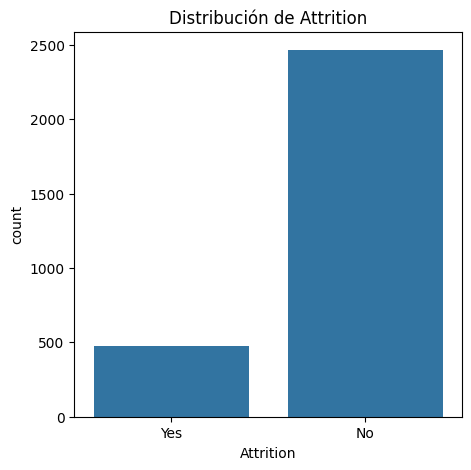

In [171]:
plt.figure(figsize=(5, 5))
sns.countplot(x='Attrition', data=df)
plt.title("Distribución de Attrition")
plt.show()

### Naturaleza del Problema y Balance de Clases
- Se trata de un problema de clasificación binaria (abandona/no abandona).
- La variable Attrition está desbalanceada: 2466 “No” (aprox. 84%) frente a 474 “Yes” (aprox. 16%). Este desbalance afecta la selección de métricas y el enfoque de entrenamiento.



## 3. Preprocesamiento de los Datos
Preprocesamiento con KNN para elegir escalado e imputación, para ello primero eliminamos las columnas constantes e irrelevantes para el modelado. Seleccionamos las columnas numéricas y categóricas, excluyendo la variable objetico 'Attrition', y codificamos la variable objetivo.


In [172]:
# Eliminar columnas constantes e irrelevantes para el modelado:
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours']
df = df.drop(columns=cols_to_drop)
# Seleccionar las columnas numéricas y categóricas (excluyendo la variable objetivo 'Attrition')
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
# Excluir Attrition
num_cols = [col for col in num_cols if col != 'Attrition']
cat_cols = [col for col in cat_cols if col != 'Attrition']
# Codificar la variable objetivo
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Attrition'])
X = df.drop(columns=['Attrition'])

### 3.1 División de Datos: Holdout (2/3 train y 1/3 test)
Se separan los datos en conjunto de entrenamiento (train) y prueba (test) para la evaluación outer.


In [173]:
# Dividir en entrenamiento y test (holdout: 2/3 train, 1/3 test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=SEED, stratify=y)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1960, 27) Test: (980, 27)


### 3.2 Pipeline
- Se prueban tres métodos de escalado (MinMax, Standard y Robust) y dos estrategias de imputación (media y mediana) mediante un pipeline combinado, evaluando cada opción con KNN usando validación cruzada.
- Y seleccionamos el que mejor resultado dé de las distintas combinaciones.

In [174]:
# Definir pipeline para variables categóricas
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
numeric_pipelines = {
    'MinMax + median': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', MinMaxScaler())]),
    'Standard + median': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]),
    'Robust + median': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler())]),
    'MinMax + mean': Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', MinMaxScaler())]),
    'Standard + mean': Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())]),
    'Robust + mean': Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', RobustScaler())])
}

inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
results_pipelines = {}

print("\nEvaluando distintos pipelines numéricos para KNN:")
for name, num_pipe in numeric_pipelines.items():
    preproc = ColumnTransformer(transformers=[
        ('num', num_pipe, num_cols),
        ('cat', categorical_pipeline, cat_cols)
    ])
    pipeline = Pipeline(steps=[
        ('preprocessing', preproc),
        ('knn', KNeighborsClassifier())
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=inner, scoring='balanced_accuracy')
    results_pipelines[name] = scores.mean()
    print(f"{name}: CV balanced accuracy = {scores.mean():.4f}")

# Seleccionar la mejor combinación
best_pipeline_name = max(results_pipelines, key=results_pipelines.get)
print("\nMejor pipeline numérico según KNN:", best_pipeline_name)


Evaluando distintos pipelines numéricos para KNN:
MinMax + median: CV balanced accuracy = 0.5757
Standard + median: CV balanced accuracy = 0.5892
Robust + median: CV balanced accuracy = 0.6121
MinMax + mean: CV balanced accuracy = 0.5757
Standard + mean: CV balanced accuracy = 0.5898
Robust + mean: CV balanced accuracy = 0.6121

Mejor pipeline numérico según KNN: Robust + median


In [175]:
# La mejor opción de escalado fue "Robust + median", definimos el pipeline definitivo:
numeric_pipeline_best = numeric_pipelines[best_pipeline_name]
preprocessing_pipeline = ColumnTransformer(transformers=[
    ('num', numeric_pipeline_best, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

## 4.Metodos Basicos: KNN y Árboles


### 4.1 Modelos Básicos: KNN y Árboles
Se entrena KNN y un Árbol de Decisión con parámetros por omisión y se miden los tiempos de entrenamiento y el rendimiento (balanced accuracy). Se incluye además un modelo dummy como referencia.

In [176]:
# KNN default
knn_default = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline),
    ('knn', KNeighborsClassifier())
])
start_time = time.time()
knn_default.fit(X_train, y_train)
knn_default_time = time.time() - start_time
knn_default_scores = cross_val_score(knn_default, X_train, y_train, cv=inner, scoring='balanced_accuracy')
print("\nKNN default:")
print("Tiempo de entrenamiento:", knn_default_time, "segundos")
print("CV Balanced Accuracy:", knn_default_scores.mean())


KNN default:
Tiempo de entrenamiento: 0.013037919998168945 segundos
CV Balanced Accuracy: 0.612092818121602


In [177]:
# Árboles default
tree_default = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline),
    ('tree', DecisionTreeClassifier(random_state=SEED))
])
start_time = time.time()
tree_default.fit(X_train, y_train)
tree_default_time = time.time() - start_time
tree_default_scores = cross_val_score(tree_default, X_train, y_train, cv=inner, scoring='balanced_accuracy')
print("\nÁrboles default:")
print("Tiempo de entrenamiento:", tree_default_time, "segundos")
print("CV Balanced Accuracy:", tree_default_scores.mean())


Árboles default:
Tiempo de entrenamiento: 0.03050827980041504 segundos
CV Balanced Accuracy: 0.7331936984498615


In [178]:
# Evaluación con un modelo trivial (dummy) para referencia
dummy = Pipeline(steps=[
    ('dummy', DummyClassifier(strategy='most_frequent'))
])
dummy_scores = cross_val_score(dummy, X_train, y_train, cv=inner, scoring='balanced_accuracy')
print("\nModelo Dummy (estrategia 'most_frequent') CV Balanced Accuracy:", dummy_scores.mean())


Modelo Dummy (estrategia 'most_frequent') CV Balanced Accuracy: 0.5


#### Hiperparámetros (HPO)
Se realiza ajuste de hiperparámetros (HPO) usando GridSearchCV y se vuelven a medir los tiempos.

- KNN HPO

In [191]:
# KNN HPO
knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}
grid_search_knn = GridSearchCV(estimator=knn_default, param_grid=knn_param_grid, cv=inner, scoring='balanced_accuracy')
start_time = time.time()
grid_search_knn.fit(X_train, y_train)
knn_hpo_time = time.time() - start_time
print("\nKNN HPO:")
print("Mejores parámetros:", grid_search_knn.best_params_)
print("Mejor CV Balanced Accuracy:", grid_search_knn.best_score_)
print("Tiempo de HPO para KNN:", knn_hpo_time, "segundos")



KNN HPO:
Mejores parámetros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Mejor CV Balanced Accuracy: 0.7804294196216798
Tiempo de HPO para KNN: 3.26175856590271 segundos


- Árboles HPO

In [194]:
# Árboles HPO
tree_param_grid = {
    'tree__max_depth': [None, 10, 15, 20, 30],
    'tree__min_samples_split': [2, 5, 10],
    'tree__min_samples_leaf': [1, 2, 4]
}
grid_search_tree = GridSearchCV(estimator=tree_default, param_grid=tree_param_grid, cv=inner, scoring='balanced_accuracy')
start_time = time.time()
grid_search_tree.fit(X_train, y_train)
tree_hpo_time = time.time() - start_time
print("\nÁrboles HPO:")
print("Mejores parámetros:", grid_search_tree.best_params_)
print("Mejor CV Balanced Accuracy:", grid_search_tree.best_score_)
print("Tiempo de HPO para Árboles:", tree_hpo_time, "segundos")


Árboles HPO:
Mejores parámetros: {'tree__max_depth': None, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 5}
Mejor CV Balanced Accuracy: 0.741508668839615
Tiempo de HPO para Árboles: 3.6427390575408936 segundos


#### Visualización del efecto de los hiperparámetros


- Efecto de n_neighbors en KNN: Se observa que al aumentar el número de vecinos, la precisión tiende a decrecer de forma lineal. Esto se debe a que, con más vecinos, se incluyen ejemplos menos similares al punto de consulta, lo que diluye la capacidad del modelo para capturar la estructura local, afectando la detección de la clase minoritaria (en este caso, “Yes”).

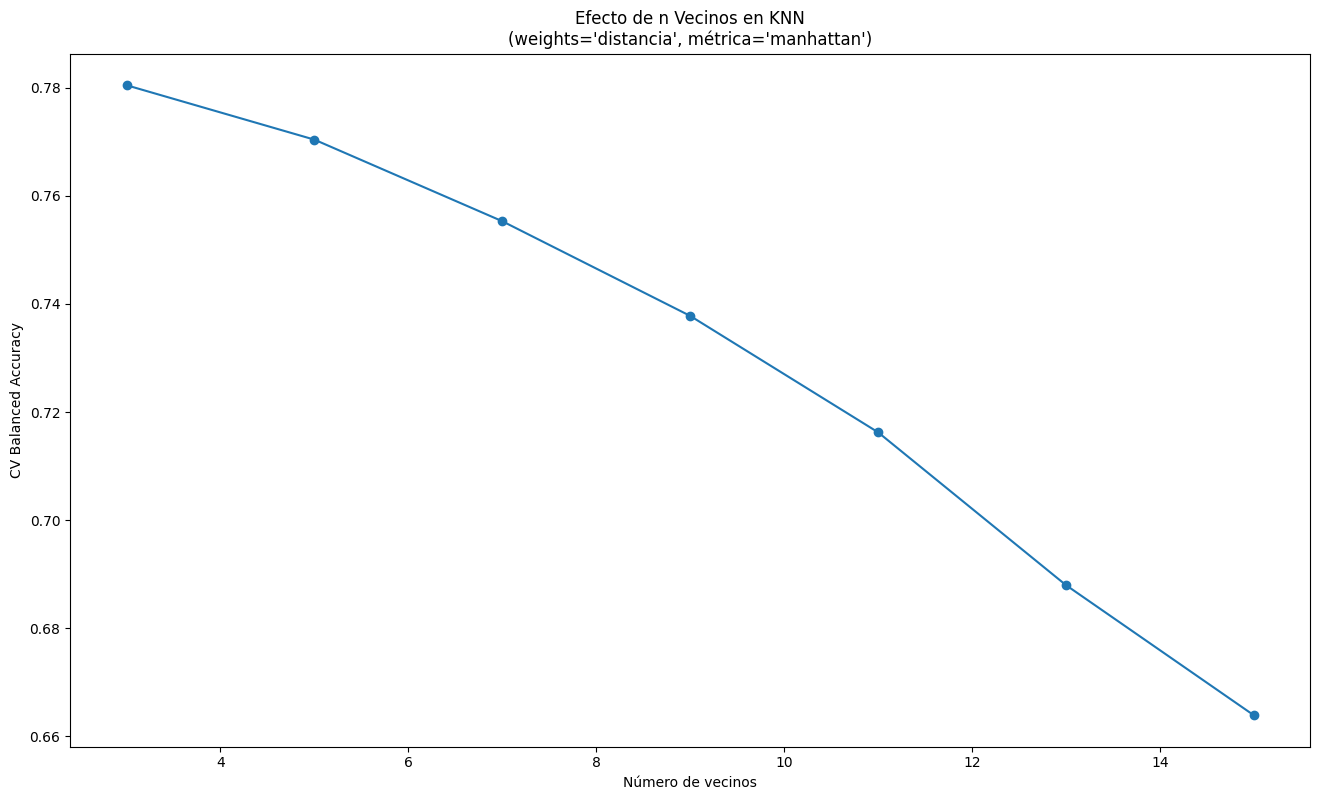

In [208]:
knn_results = grid_search_knn.cv_results_['mean_test_score']
neighbors = knn_param_grid['knn__n_neighbors']
# Como GridSearch evalúa combinaciones, se puede extraer el efecto de n_neighbors para un valor fijo de weights y metric,
# por ejemplo, weights='distance' y metric='manhattan'.
selected_indices = [i for i, params in enumerate(grid_search_knn.cv_results_['params'])
                    if params['knn__weights']=='distance' and params['knn__metric']=='manhattan']
neighbors_scores = [grid_search_knn.cv_results_['mean_test_score'][i] for i in selected_indices]

plt.figure(figsize=(16,9))
plt.plot(neighbors, neighbors_scores, marker='o', linestyle='-')
plt.xlabel("Número de vecinos")
plt.ylabel("CV Balanced Accuracy")
plt.title("Efecto de n Vecinos en KNN\n(weights='distancia', métrica='manhattan')")
plt.show()

- Efecto de max_depth en Árboles: La gráfica muestra que la precisión aumenta a medida que se incrementa la profundidad, pero a partir de un cierto punto (por ejemplo, profundidad mayor o igual que 20) la precisión se estabiliza. Este comportamiento sugiere una función de tipo logarítmica: al aumentar la profundidad, se obtiene más información hasta que el árbol ya no mejora sustancialmente su capacidad predictiva, lo que además ayuda a evitar el sobreajuste.

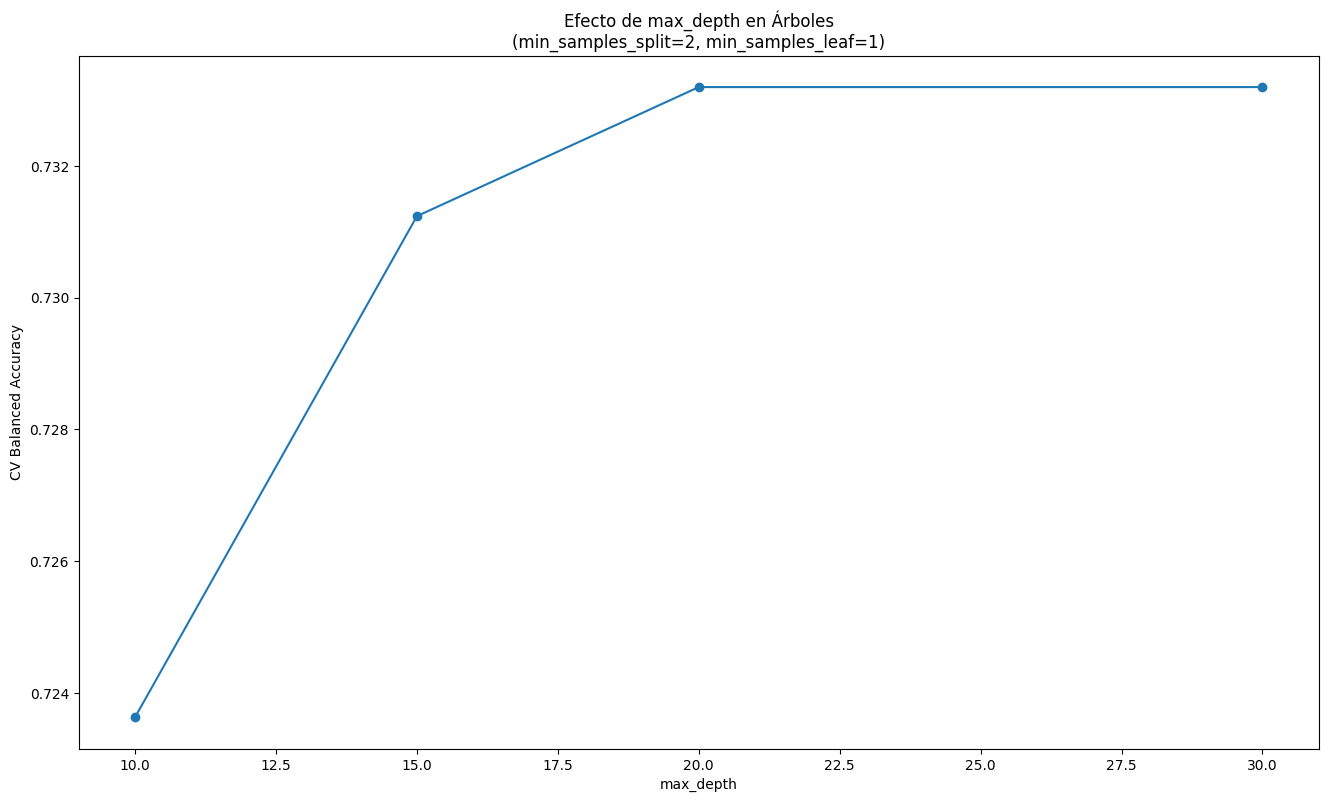

In [209]:
tree_results = grid_search_tree.cv_results_['mean_test_score']
max_depths = tree_param_grid['tree__max_depth']
# Filtramos para un valor fijo de min_samples_split y min_samples_leaf, por ejemplo, min_samples_split=2, min_samples_leaf=1
selected_indices_tree = [i for i, params in enumerate(grid_search_tree.cv_results_['params'])
                         if params['tree__min_samples_split']==2 and params['tree__min_samples_leaf']==1]
depth_scores = [grid_search_tree.cv_results_['mean_test_score'][i] for i in selected_indices_tree]

plt.figure(figsize=(16, 9))
plt.plot(max_depths, depth_scores, marker='o', linestyle='-')
plt.xlabel("max_depth")
plt.ylabel("CV Balanced Accuracy")
plt.title("Efecto de max_depth en Árboles\n(min_samples_split=2, min_samples_leaf=1)")
plt.show()

- Efecto de min_samples_split en Árboles: La gráfica ilustra el efecto de ajustar el parámetro min_samples_split con max_depth y min_samples_leaf fijados. Un valor muy bajo puede causar sobreajuste, ya que el árbol se divide con muy pocos datos, mientras que un valor demasiado alto impide divisiones significativas, reduciendo la capacidad predictiva. La gráfica ayuda a visualizar el equilibrio entre complejidad y generalización.

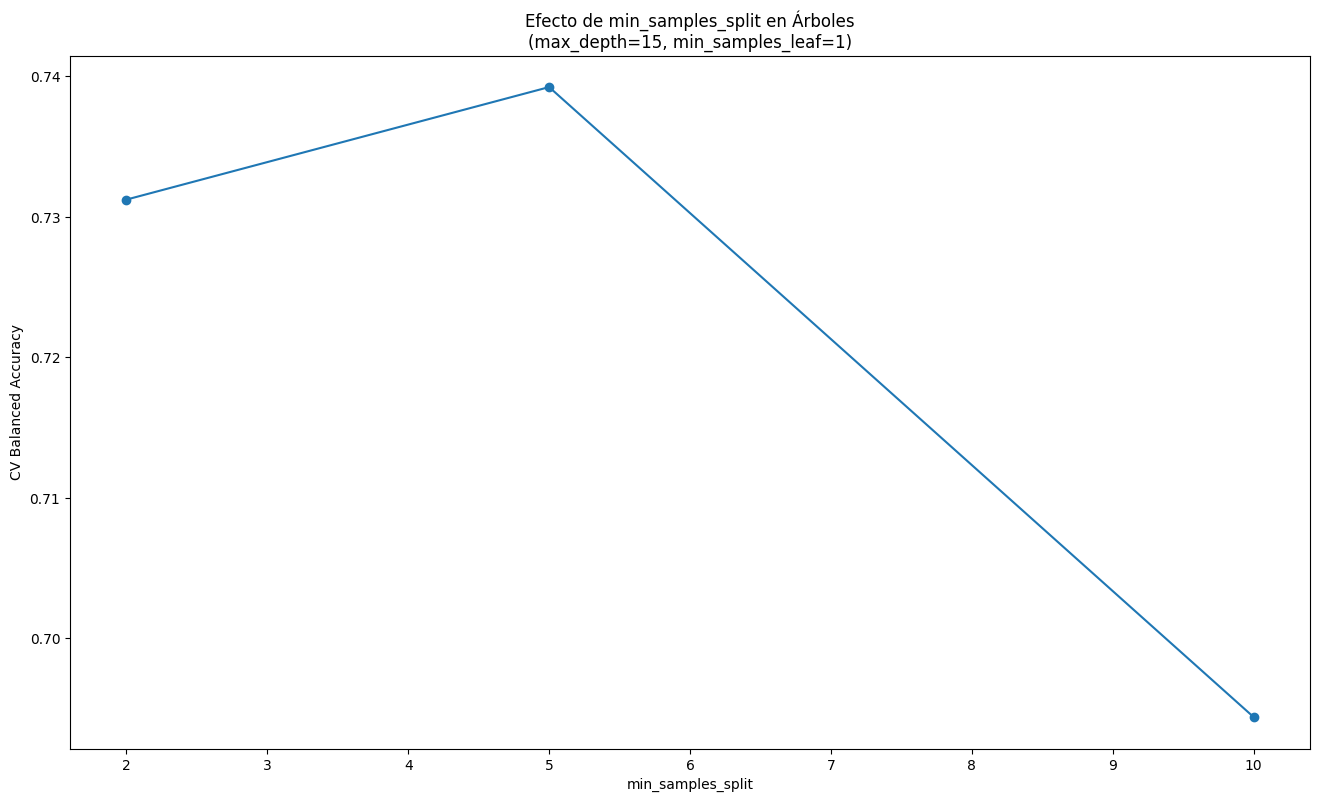

In [212]:
# Para esta gráfica, fijamos max_depth a un valor (por ejemplo, 15) y min_samples_leaf a 1
# Se extraen las combinaciones con max_depth == 15 y min_samples_leaf == 1
selected_indices_split = [i for i, params in enumerate(grid_search_tree.cv_results_['params'])
                          if params['tree__max_depth'] == 15 and params['tree__min_samples_leaf'] == 1]
split_values = [grid_search_tree.cv_results_['params'][i]['tree__min_samples_split'] for i in selected_indices_split]
split_scores = [grid_search_tree.cv_results_['mean_test_score'][i] for i in selected_indices_split]

plt.figure(figsize=(16,9))
plt.plot(split_values, split_scores, marker='o', linestyle='-')
plt.xlabel("min_samples_split")
plt.ylabel("CV Balanced Accuracy")
plt.title("Efecto de min_samples_split en Árboles\n(max_depth=15, min_samples_leaf=1)")
plt.show()

- ¿Cuál es el mejor método? 


- ¿Los resultados son mejores que los modelos triviales/naive/dummy? 


- ¿El ajuste de hiperparámetros mejora con respecto a los valores por omisión? 

- ¿Si hay mejora, es el coste computacional elevado? ¿A qué coste computacional? 


### 4.2 Modelos Avanzados: Regresión Logística y SVM

#### Regresión Logística Default
Entrenamos un modelo de Regresión Logística con parámetros por defecto y medimos el tiempo de entrenamiento.


In [184]:
## Creamos un pipeline que utiliza el preprocesamiento ya definido y añade el modelo de Regresión Logística
log_reg_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline),
    ('log_reg', LogisticRegression(max_iter=1000, solver='liblinear', random_state=SEED))
])

# Entrenamiento del modelo con parámetros por defecto
start_time = time.time()
log_reg_pipeline.fit(X_train, y_train)
log_reg_time = time.time() - start_time
print("Tiempo de entrenamiento Regresión Logística (default): {:.4f} segundos".format(log_reg_time))

# Evaluación en el conjunto de entrenamiento
#y_pred_log = log_reg_pipeline.predict(X_train)
#print("Balanced Accuracy Regresión Logística (default):", balanced_accuracy_score(y_train, y_pred_log))

cv_scores = cross_val_score(log_reg_pipeline, X_train, y_train, scoring='balanced_accuracy', cv = inner)
print("Cross-validation balanced accuracy scores: ", cv_scores)
print("Mean cross-validation balanced accuracy: {:.4f}".format(cv_scores.mean()))

Tiempo de entrenamiento Regresión Logística (default): 0.0165 segundos
Cross-validation balanced accuracy scores:  [0.63452004 0.60647376 0.59694995]
Mean cross-validation balanced accuracy: 0.6126


#### Regresión Logística HPO
Realizamos una búsqueda de hiperparámetros para optimizar el modelo de Regresión Logística.
Ajustamos el parámetro de regularización C y la penalización (l1 y l2).


In [185]:
# Definimos el grid de hiperparámetros para la Regresión Logística
log_reg_param_grid = {
    'log_reg__C': [0.01, 0.1, 1, 10, 100],
    'log_reg__penalty': ['l1', 'l2']  # Usamos 'liblinear', que soporta ambas penalizaciones.
}

# Realizamos la búsqueda de hiperparámetros con validación cruzada interna
grid_search_log = GridSearchCV(estimator=log_reg_pipeline, 
                               param_grid=log_reg_param_grid, 
                               cv=inner, 
                               scoring='balanced_accuracy')
grid_search_log.fit(X_train, y_train)

print("Mejores parámetros para Regresión Logística:", grid_search_log.best_params_)
print("Mejor balanced accuracy Regresión Logística:", grid_search_log.best_score_)

Mejores parámetros para Regresión Logística: {'log_reg__C': 10, 'log_reg__penalty': 'l1'}
Mejor balanced accuracy Regresión Logística: 0.6149101090190472


#### SVM Default
Entrenamos un modelo SVM con parámetros por defecto y medimos el tiempo de entrenamiento.

In [186]:
# Creamos un pipeline para SVM que incluye el preprocesamiento
svm_pipeline_default = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline),
    ('svm', SVC(random_state=SEED))
])

# Entrenamiento del modelo SVM con parámetros por defecto
start_time = time.time()
svm_pipeline_default.fit(X_train, y_train)
svm_time = time.time() - start_time
print("Tiempo de entrenamiento SVM (default): {:.4f} segundos".format(svm_time))

# Evaluación en el conjunto de entrenamiento
#y_pred_svm = svm_pipeline_default.predict(X_train)
#print("Balanced Accuracy SVM (default):", balanced_accuracy_score(y_train, y_pred_svm))
cv_scores = cross_val_score(svm_pipeline_default, X_train, y_train, scoring='balanced_accuracy', cv = inner)
print("Cross-validation balanced accuracy scores: ", cv_scores)
print("Mean cross-validation balanced accuracy: {:.4f}".format(cv_scores.mean()))

Tiempo de entrenamiento SVM (default): 0.0570 segundos
Cross-validation balanced accuracy scores:  [0.63116306 0.62512165 0.58206465]
Mean cross-validation balanced accuracy: 0.6128


#### SVM HPO
- Realizamos la búsqueda de hiperparámetros para optimizar el modelo SVM.
- Ajustamos el parámetro C y el tipo de kernel (lineal y RBF).

In [187]:
# Creamos nuevamente el pipeline para SVM (para mayor claridad)
svm_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline),
    ('svm', SVC(random_state=SEED))
])

# Definimos el grid de hiperparámetros para SVM
svm_param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

# Búsqueda de hiperparámetros con validación cruzada interna
grid_search_svm = GridSearchCV(estimator=svm_pipeline, 
                               param_grid=svm_param_grid, 
                               cv=inner, 
                               scoring='balanced_accuracy')
grid_search_svm.fit(X_train, y_train)

print("Mejores parámetros para SVM:", grid_search_svm.best_params_)
print("Mejor balanced accuracy SVM:", grid_search_svm.best_score_)

Mejores parámetros para SVM: {'svm__C': 10, 'svm__kernel': 'rbf'}
Mejor balanced accuracy SVM: 0.8128430755307218


In [188]:

data_path = './lab1/data/attrition_competition_05.csv'
df_new = pd.read_csv(data_path)

# Preprocesar los datos (asegúrate de que el preprocesamiento sea el mismo que el usado en el entrenamiento)
X_new = df_new.drop(columns=['EmployeeID','EmployeeCount'])
# Realizar las predicciones
predictions = grid_search_svm.predict(X_new)

# Crear un DataFrame con los resultados
results = pd.DataFrame({
    'EmployeeID': df_new['EmployeeID'],
    'Attrition': predictions
})
results.to_csv("predicciones.csv", index=False)
print("Archivo 'predicciones.csv' guardado correctamente.")
# Imprimir los resultados
print(results)

ValueError: columns are missing: {'EmployeeID'}